In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Load Libraries

In [2]:
#!pip uninstall tensorflow


In [3]:
#!pip install tensorflow==2.7.0


In [4]:
import os
import numpy as np
import cv2
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
#from keras.utils import to_categorical
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import numpy as np
import keras
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalMaxPooling2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras.utils.vis_utils import plot_model
from collections import Counter
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score

# Load radiologist report/ ground truth

In [5]:
# read by default 1st sheet of an excel file
# set project directory
proj_dir = '/content/drive/MyDrive/LUMBAR_SPINE/'

# read excel file using pandas
df = pd.read_excel(proj_dir + 'Radiologists Report.xlsx') 

# fill NaN values in 'Clinician's Notes' column with 0
df["Clinician's Notes"] = df["Clinician's Notes"].fillna("0") 

# create labels
y_label = []
for i in range(len(df)):

  ############unhealthy##############
    # check if 'L4', 'L5', or 'S1' is present in the 'Clinician's Notes' column
    if "L4" in df["Clinician's Notes"][i] or "L5" in df["Clinician's Notes"][i] or "S1" in df["Clinician's Notes"][i]:
        y_label.append(1)
  ###################################

  ###########healthy######################
    else:
        y_label.append(0)
  ###########################################

# convert the list to numpy array
y_label = np.array(y_label)


In [6]:
images_path=proj_dir+'05_Final_Ground_Truth_Data/Composite_Images/'
imgs=os.listdir(images_path)

In [7]:
# Pad patient IDs with leading zeros if necessary
df["Patient ID"] = df["Patient ID"].apply(lambda x: "0"*(4-len(str(x)))+str(x)) #get the id of each patient

# Create an array of patient IDs
ids = np.array(df["Patient ID"])

# Create an array of labels for each image
y_label_final = []
for i in range(len(imgs)):
    # Get the patient ID from the image filename
    id = imgs[i].split('_')[1]
    # Find the index of the matching patient ID in the array of IDs and append the corresponding label to y_label_final
    y_label_final.append(y_label[np.where(ids==id)[0][0]])


In [8]:
# Split the labels into training and testing sets
# using train_test_split function from scikit-learn
# with test_size=0.10 i.e. 10% of data as test set
# and random_state=42 for reproducibility
y_train, y_test = train_test_split(np.array(y_label_final), test_size=0.10, random_state=42)


# Load training data

In [9]:
proj_dir='/content/drive/MyDrive/LUMBAR_SPINE/'
X_train=np.load(proj_dir+'ROI_train.npy',allow_pickle = True)
X_test=np.load(proj_dir+'ROI_test.npy', allow_pickle = True)
X_train=np.load(proj_dir+'ENH_train.npy',allow_pickle = True)
X_test=np.load(proj_dir+'ENH_test.npy', allow_pickle = True)

In [10]:
X_train.shape,y_train.shape

((1390, 64, 64), (1390,))

# Build model

In [11]:
# Set the number of classes to 2
K = 2

# Print the number of classes
print("number of classes:", K)


# Build the model using the functional API
# Define the input layer with shape (64, 64, 1)
i = Input(shape=(64, 64, 1))

# Add convolutional layers with 32 filters, each with a size of (3,3), ReLU activation, and 'same' padding
x = Conv2D(32, (3, 3), activation='relu', padding='same')(i)
x = BatchNormalization()(x) # Add batch normalization
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x) # Add batch normalization
x = MaxPooling2D((2, 2))(x) # Add max pooling with a pool size of (2,2)

# Add convolutional layers with 64 filters, each with a size of (3,3), ReLU activation, and 'same' padding
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x) # Add batch normalization
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x) # Add batch normalization
x = MaxPooling2D((2, 2))(x) # Add max pooling with a pool size of (2,2)

# Add convolutional layers with 128 filters, each with a size of (3,3), ReLU activation, and 'same' padding
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x) # Add batch normalization
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x) # Add batch normalization
x = MaxPooling2D((2, 2))(x) # Add max pooling with a pool size of (2,2)

x = Flatten()(x) # Flatten the output from the convolutional layers
x = Dropout(0.2)(x) # Add dropout with a rate of 0.2

# Add a fully connected layer with 1024 units and ReLU activation
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x) # Add dropout with a rate of 0.2

# Add a fully connected layer with softmax activation for output layer
x = Dense(K, activation='softmax')(x)

# Create a model that takes in the input layer and outputs the output layer
model = Model(i, x)

# Print the model summary
model.summary()


number of classes: 2
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 32,

# Train Model

In [12]:
# Compile the model with appropriate optimizer, loss function and evaluation metric
model.compile(optimizer='adam',
			loss='sparse_categorical_crossentropy',
			metrics=['accuracy'])


In [13]:
###train the model###############
batch_size = 128

####data augmentation############################
# Create a data generator object to perform data augmentation
data_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.1,   # Randomly shift the width of the image by a maximum of 10%
    height_shift_range=0.1,  # Randomly shift the height of the image by a maximum of 10%
    horizontal_flip=True     # Flip the image horizontally randomly
)

# Reshape the training and testing data to be compatible with the data generator
X_train = X_train.reshape(-1, 64, 64, 1)
X_test = X_test.reshape(-1, 64, 64, 1)

# Create a batch data generator from the data generator and the training data
train_generator = data_generator.flow(X_train, y_train, batch_size)
###############################################################################


# Define the number of steps per epoch based on the size of the training set and batch size
steps_per_epoch = X_train.shape[0] // batch_size

# Train the model using the training generator and validation data
# steps_per_epoch determines the number of batches in each epoch
# epochs is the number of times to iterate over the entire training set
history = model.fit(train_generator, validation_data=(X_test, y_test),
                    steps_per_epoch=steps_per_epoch, epochs=50)


Epoch 1/50
10/10 [==============================] - 18s 299ms/step - loss: 11.4312 - accuracy: 0.6751 - val_loss: 162.1577 - val_accuracy: 0.7613
Epoch 2/50
10/10 [==============================] - 1s 78ms/step - loss: 0.9254 - accuracy: 0.6852 - val_loss: 101.6047 - val_accuracy: 0.7613
Epoch 3/50
10/10 [==============================] - 1s 79ms/step - loss: 0.7009 - accuracy: 0.7805 - val_loss: 53.5974 - val_accuracy: 0.7613
Epoch 4/50
10/10 [==============================] - 1s 77ms/step - loss: 0.5578 - accuracy: 0.7853 - val_loss: 30.3489 - val_accuracy: 0.7613
Epoch 5/50
10/10 [==============================] - 1s 78ms/step - loss: 0.5637 - accuracy: 0.7829 - val_loss: 14.6401 - val_accuracy: 0.7548
Epoch 6/50
10/10 [==============================] - 1s 79ms/step - loss: 0.5212 - accuracy: 0.7924 - val_loss: 8.1280 - val_accuracy: 0.7355
Epoch 7/50
10/10 [==============================] - 1s 82ms/step - loss: 0.5317 - accuracy: 0.7914 - val_loss: 5.5643 - val_accuracy: 0.4645
Epo

# Evaluate the model

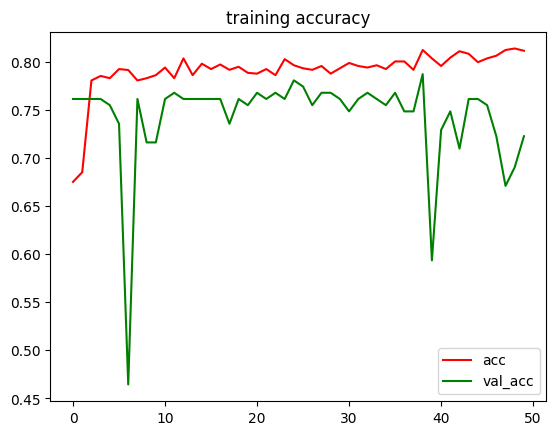

In [14]:
# Plot accuracy per iteration
plt.plot(history.history['accuracy'], label='acc', color='red')  # plot training accuracy values
plt.plot(history.history['val_accuracy'], label='val_acc', color='green')  # plot validation accuracy values
plt.title('training accuracy')  # set the title of the plot
plt.legend()  # show legend
plt.show()  # display the plot


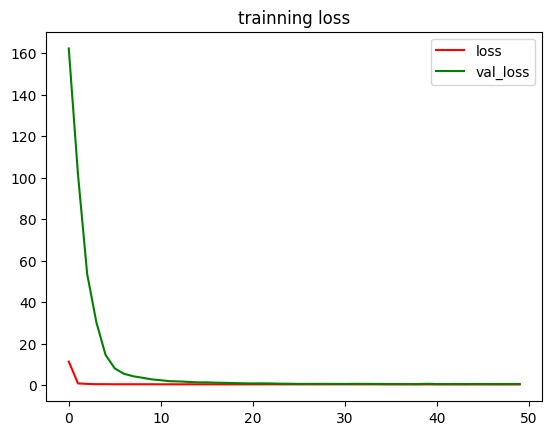

In [15]:
# plot the training and validation loss over epochs
plt.plot(history.history['loss'], label='loss', color='red')  # plot the training loss over epochs
plt.plot(history.history['val_loss'], label='val_loss', color='green')  # plot the validation loss over epochs
plt.title('trainning loss')  # set the title of the plot
plt.legend()  # add the legend to the plot
plt.show()  # display the plot


In [16]:
def confusion_mat(y,y_pred):
  # create a confusion matrix
  cf_matrix = confusion_matrix(y,y_pred)
  
  # print the confusion matrix
  print(cf_matrix)
  
  # create a heatmap of the confusion matrix using seaborn
  ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues')
  
  # set the title of the heatmap
  ax.set_title('Seaborn Confusion Matrix with labels.model1\n\n')
  
  # set the label for the x-axis of the heatmap
  ax.set_xlabel('\nPredicted Values')
  
  # set the label for the y-axis of the heatmap
  ax.set_ylabel('Actual Values ')
  
  # show the heatmap
  plt.show()


In [17]:
def stat_report(y,y_pred):
  accuracy = accuracy_score(y,y_pred)
  print('Accuracy: %f' % accuracy)
  # precision tp / (tp + fp)
  precision = precision_score(y,y_pred)
  print('Precision: %f' % precision)
  # recall: tp / (tp + fn)
  recall = recall_score(y,y_pred)
  print('Recall: %f' % recall)
  # f1: 2 tp / (2 tp + fp + fn)
  f1 = f1_score(y,y_pred)
  print('F1 score: %f' % f1)

### **Train** **Data**

In [18]:
# Predict on the training set and get the predicted class labels
y_pred = model.predict(X_train)
y_pred = np.argmax(y_pred, axis=1)


44/44 [==============================] - 0s 7ms/step


[[132 158]
 [137 963]]


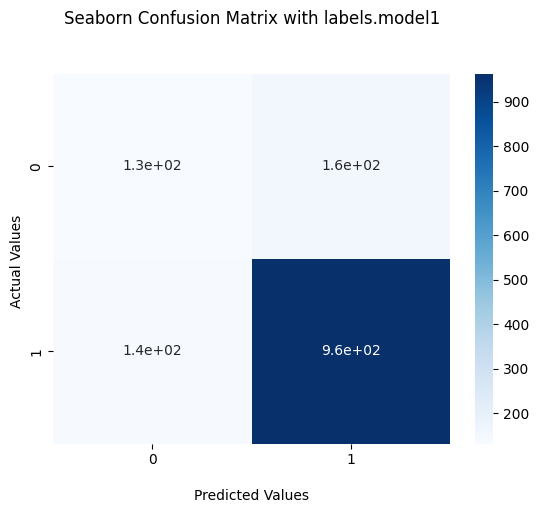

In [19]:
confusion_mat(y_train,y_pred)

In [20]:
  stat_report(y_train,y_pred)

Accuracy: 0.787770
Precision: 0.859054
Recall: 0.875455
F1 score: 0.867177


### Test Data

In [21]:
# Predict the labels for the test data
y_pred = model.predict(X_test)

# Convert the predicted probabilities to predicted class labels
y_pred = np.argmax(y_pred, axis=1)


5/5 [==============================] - 0s 4ms/step


[[ 11  26]
 [ 17 101]]


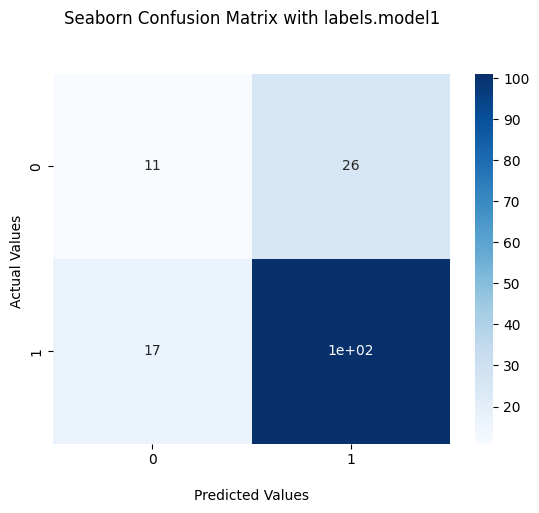

In [22]:
confusion_mat(y_test,y_pred)

In [23]:
stat_report(y_test,y_pred)

Accuracy: 0.722581
Precision: 0.795276
Recall: 0.855932
F1 score: 0.824490
